In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


# Understanding our Data 

In [5]:
df = pd.read_csv("Canadian_Health_Survey_Sample.csv")



In [6]:
df.head()

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
0,Ontario,female,59,80572.0,25.7,3.8,yes,Good,6.0
1,New Brunswick,Male,38,125739.0,24.2,3.4,No,Good,9.0
2,Nova Scotia,M,31,55997.0,35.7,NaN,No,Excellent,NaN
3,Saskatchewan,Male,30,75947.0,28.3,3.9,No,Excellent,10.0
4,Saskatchewan,female,79,113966.0,31.2,1.6,No,Fair,6.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          850 non-null    str    
 1   Gender            850 non-null    str    
 2   Age               850 non-null    int64  
 3   Income            816 non-null    float64
 4   BMI               808 non-null    float64
 5   PhysicalActivity  825 non-null    float64
 6   Smoking           850 non-null    str    
 7   SelfRatedHealth   850 non-null    str    
 8   StressLevel       825 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 59.9 KB


In [8]:
df.describe(include='all')

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
count,850,850,850.000000,816.000000,808.000000,825.000000,850,850,825.000000
unique,10,6,NaN,NaN,NaN,NaN,6,5,NaN
top,Quebec,Male,NaN,NaN,NaN,NaN,No,Good,NaN
freq,100,230,NaN,NaN,NaN,NaN,552,258,NaN
mean,NaN,NaN,49.517647,77461.917892,27.488861,3.511394,NaN,NaN,5.294545
std,NaN,NaN,18.192604,22497.833440,5.064344,1.925825,NaN,NaN,2.121156
min,NaN,NaN,18.000000,5000.000000,13.500000,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,33.000000,63438.000000,24.000000,2.100000,NaN,NaN,4.000000
50%,NaN,NaN,49.000000,78130.000000,27.300000,3.500000,NaN,NaN,5.000000
75%,NaN,NaN,66.000000,90529.500000,30.900000,4.700000,NaN,NaN,7.000000


**Quantitative Attribute:** One numerically measurable property in this dataset is age. Is numerical, can do mathematics on the value through graophs, calculations, median & mode, etc. 


**Qualitative Attribute:** Physical Activity because it is not numerical value, and can be very nuanced answer depending on the person they get data from. Can range from doesnt work out at all to very active/elite athlete 

# Cleaning & Structuring 




**Standardizing Categorical Values:**

In [9]:
print(df)

                      Province  Gender  Age    Income   BMI  PhysicalActivity  \
0                      Ontario  female   59   80572.0  25.7               3.8   
1                New Brunswick    Male   38  125739.0  24.2               3.4   
2                  Nova Scotia       M   31   55997.0  35.7               NaN   
3                 Saskatchewan    Male   30   75947.0  28.3               3.9   
4                 Saskatchewan  female   79  113966.0  31.2               1.6   
..                         ...     ...  ...       ...   ...               ...   
845                    Ontario       F   68  102355.0  25.5               6.3   
846                     Quebec  Female   46       NaN  13.7               3.0   
847                    Ontario  Female   78  108434.0  24.1               3.5   
848  Newfoundland and Labrador    male   18   85176.0  24.6               5.3   
849                Nova Scotia    Male   63   96105.0   NaN               5.7   

    Smoking SelfRatedHealth

In [26]:
df["Gender"].value_counts()

Gender
Male      230
Female    217
male      133
female    126
M          76
F          68
Name: count, dtype: int64

In [58]:
df["Gender"] = df["Gender"].str.lower() 

df["Gender"] = df["Gender"].replace({"male":"Male"})
df["Gender"] = df["Gender"].replace({"m":"Male"})
df["Gender"] = df["Gender"].replace({"female":"Female"})
df["Gender"] = df["Gender"].replace({"f":"Female"})

In [59]:
df["Gender"].value_counts()

Gender
Male      439
Female    411
Name: count, dtype: int64

In [44]:
df["Smoking"].value_counts()

Smoking
No     552
Yes    149
N       73
no      34
Y       26
yes     16
Name: count, dtype: int64

In [56]:
df["Smoking"] = df["Smoking"].str.lower()

df["Smoking"] = df["Smoking"].replace({"n":"No"})
df["Smoking"] = df["Smoking"].replace({"no":"No"})
df["Smoking"] = df["Smoking"].replace({"yes":"Yes"})
df["Smoking"] = df["Smoking"].replace({"y":"Yes"})

In [57]:
df["Smoking"].value_counts()

Smoking
No     659
Yes    191
Name: count, dtype: int64

In [60]:
print(df)

                      Province  Gender  Age    Income   BMI  PhysicalActivity  \
0                      Ontario  Female   59   80572.0  25.7               3.8   
1                New Brunswick    Male   38  125739.0  24.2               3.4   
2                  Nova Scotia    Male   31   55997.0  35.7               NaN   
3                 Saskatchewan    Male   30   75947.0  28.3               3.9   
4                 Saskatchewan  Female   79  113966.0  31.2               1.6   
..                         ...     ...  ...       ...   ...               ...   
845                    Ontario  Female   68  102355.0  25.5               6.3   
846                     Quebec  Female   46       NaN  13.7               3.0   
847                    Ontario  Female   78  108434.0  24.1               3.5   
848  Newfoundland and Labrador    Male   18   85176.0  24.6               5.3   
849                Nova Scotia    Male   63   96105.0   NaN               5.7   

    Smoking SelfRatedHealth

In [10]:
df.isnull().sum()

Province             0
Gender               0
Age                  0
Income              34
BMI                 42
PhysicalActivity    25
Smoking              0
SelfRatedHealth      0
StressLevel         25
dtype: int64

In [11]:
df.isnull().mean()
print(df)

                      Province  Gender  Age    Income   BMI  PhysicalActivity  \
0                      Ontario  female   59   80572.0  25.7               3.8   
1                New Brunswick    Male   38  125739.0  24.2               3.4   
2                  Nova Scotia       M   31   55997.0  35.7               NaN   
3                 Saskatchewan    Male   30   75947.0  28.3               3.9   
4                 Saskatchewan  female   79  113966.0  31.2               1.6   
..                         ...     ...  ...       ...   ...               ...   
845                    Ontario       F   68  102355.0  25.5               6.3   
846                     Quebec  Female   46       NaN  13.7               3.0   
847                    Ontario  Female   78  108434.0  24.1               3.5   
848  Newfoundland and Labrador    male   18   85176.0  24.6               5.3   
849                Nova Scotia    Male   63   96105.0   NaN               5.7   

    Smoking SelfRatedHealth

In [12]:
df["Income"] = df["Income"].fillna(df["Income"].median())
df["BMI"] = df["BMI"].fillna(df["BMI"].median())
df["StressLevel"] = df["StressLevel"].fillna(df["StressLevel"].median())
df["PhysicalActivity"] = df["PhysicalActivity"].fillna(df["PhysicalActivity"].median())

In [13]:
print(df)

                      Province  Gender  Age    Income   BMI  PhysicalActivity  \
0                      Ontario  female   59   80572.0  25.7               3.8   
1                New Brunswick    Male   38  125739.0  24.2               3.4   
2                  Nova Scotia       M   31   55997.0  35.7               3.5   
3                 Saskatchewan    Male   30   75947.0  28.3               3.9   
4                 Saskatchewan  female   79  113966.0  31.2               1.6   
..                         ...     ...  ...       ...   ...               ...   
845                    Ontario       F   68  102355.0  25.5               6.3   
846                     Quebec  Female   46   78130.0  13.7               3.0   
847                    Ontario  Female   78  108434.0  24.1               3.5   
848  Newfoundland and Labrador    male   18   85176.0  24.6               5.3   
849                Nova Scotia    Male   63   96105.0  27.3               5.7   

    Smoking SelfRatedHealth

For each four columns, I chose Imputation due to each value not only being numerical, but also many numerical values being skewed and or outliers in the numerical data in the column. 

**Example:** Income column, one person makes $55,997 annually, another makes 125,739 anually.

# Enforcing Data Types

In [16]:
df.dtypes

Province                str
Gender                  str
Age                   int64
Income              float64
BMI                 float64
PhysicalActivity    float64
Smoking                 str
SelfRatedHealth         str
StressLevel         float64
dtype: object

In [17]:
df["Age"] = df["Age"].astype(int)
df["Income"] = df["Income"].astype(float)
df["BMI"] = df["BMI"].astype(float)
df["StressLevel"] = df["StressLevel"].astype(int)

In [18]:
df.dtypes

Province                str
Gender                  str
Age                   int64
Income              float64
BMI                 float64
PhysicalActivity    float64
Smoking                 str
SelfRatedHealth         str
StressLevel           int64
dtype: object

## We Create Derived Columns

In [20]:
bins = [0, 18.5, 24.9, 29.9, float("inf")]
labels = ["Underweight","Normal","Overweight","Obese"]

df["BMI_Category"] = pd.cut(df["BMI"], bins = bins, labels = labels)

df["BMI_Category"].value_counts()

BMI_Category
Overweight     343
Obese          251
Normal         225
Underweight     31
Name: count, dtype: int64

In [21]:
incomebins = [0, 50000, 80000, 110000, float("inf")]
incomelabels = ["<50k","50–80k","80–110k",">110k"]
df["IncomeBracket"] = pd.cut(df["Income"], bins = incomebins, labels = incomelabels)

df["IncomeBracket"].value_counts()









IncomeBracket
50–80k     411
80–110k    323
<50k        75
>110k       41
Name: count, dtype: int64

In [8]:
healthmap = {"Poor": 1, "Fair": 2, "Good": 3, "Very Good": 4, "Excellent": 5}
df["SelfRatedHealth_num"] = df["SelfRatedHealth"].map(healthmap)


In [9]:
province_health = df.groupby("Province")["SelfRatedHealth_num"].mean()

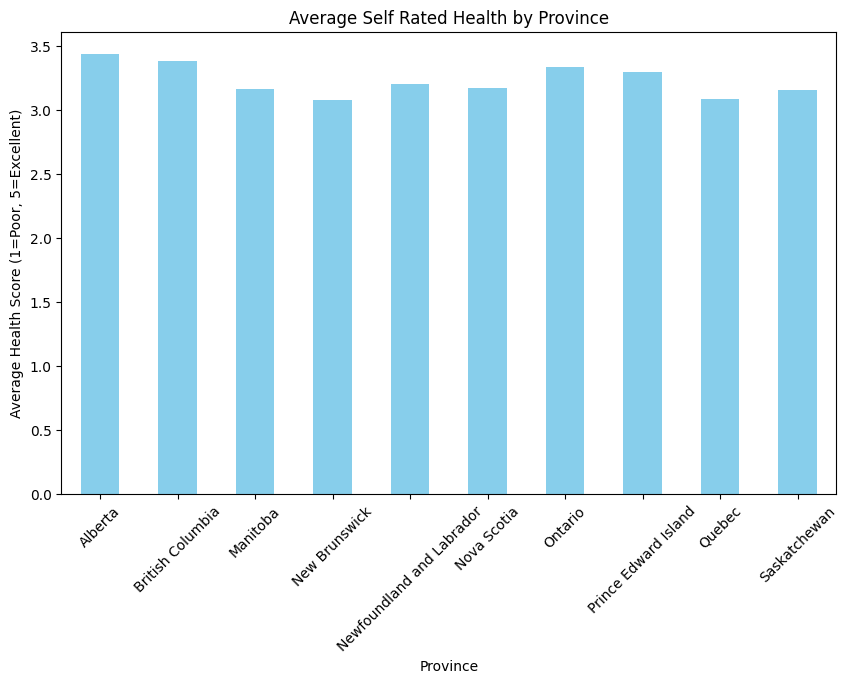

In [10]:
plt.figure(figsize=(10,6))
province_health.plot(kind="bar", color="skyblue")
plt.title("Average Self Rated Health by Province")
plt.xlabel("Province")
plt.ylabel("Average Health Score (1=Poor, 5=Excellent)")
plt.xticks(rotation=45)
plt.show()